> **Prerequisite:** Run earlier notebooks in numeric order in the **same kernel session**.

# 03 — Main figure

Build and export the composite figure (PDF, PNG, SVG, EPS).

N = 43 participants


Regression F=7.89, p=0.0013, R^2=0.283
Dispersion-RT r=0.44, p=0.0035
Moderation interaction b3=0.371, p=0.0191
Moderated mediation index=0.122, CI [0.001, 0.288]


panel a embedding: empirical (panel_a_g12_parcels.csv, n=563 parcels)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved Figure (600 DPI, transparent) to d:\文件同步\文件\数据分析结果\data_code_figure\gradient_dispersion_mediate_moderate\figures\macro_gradients_topographic_fidelity.pdf


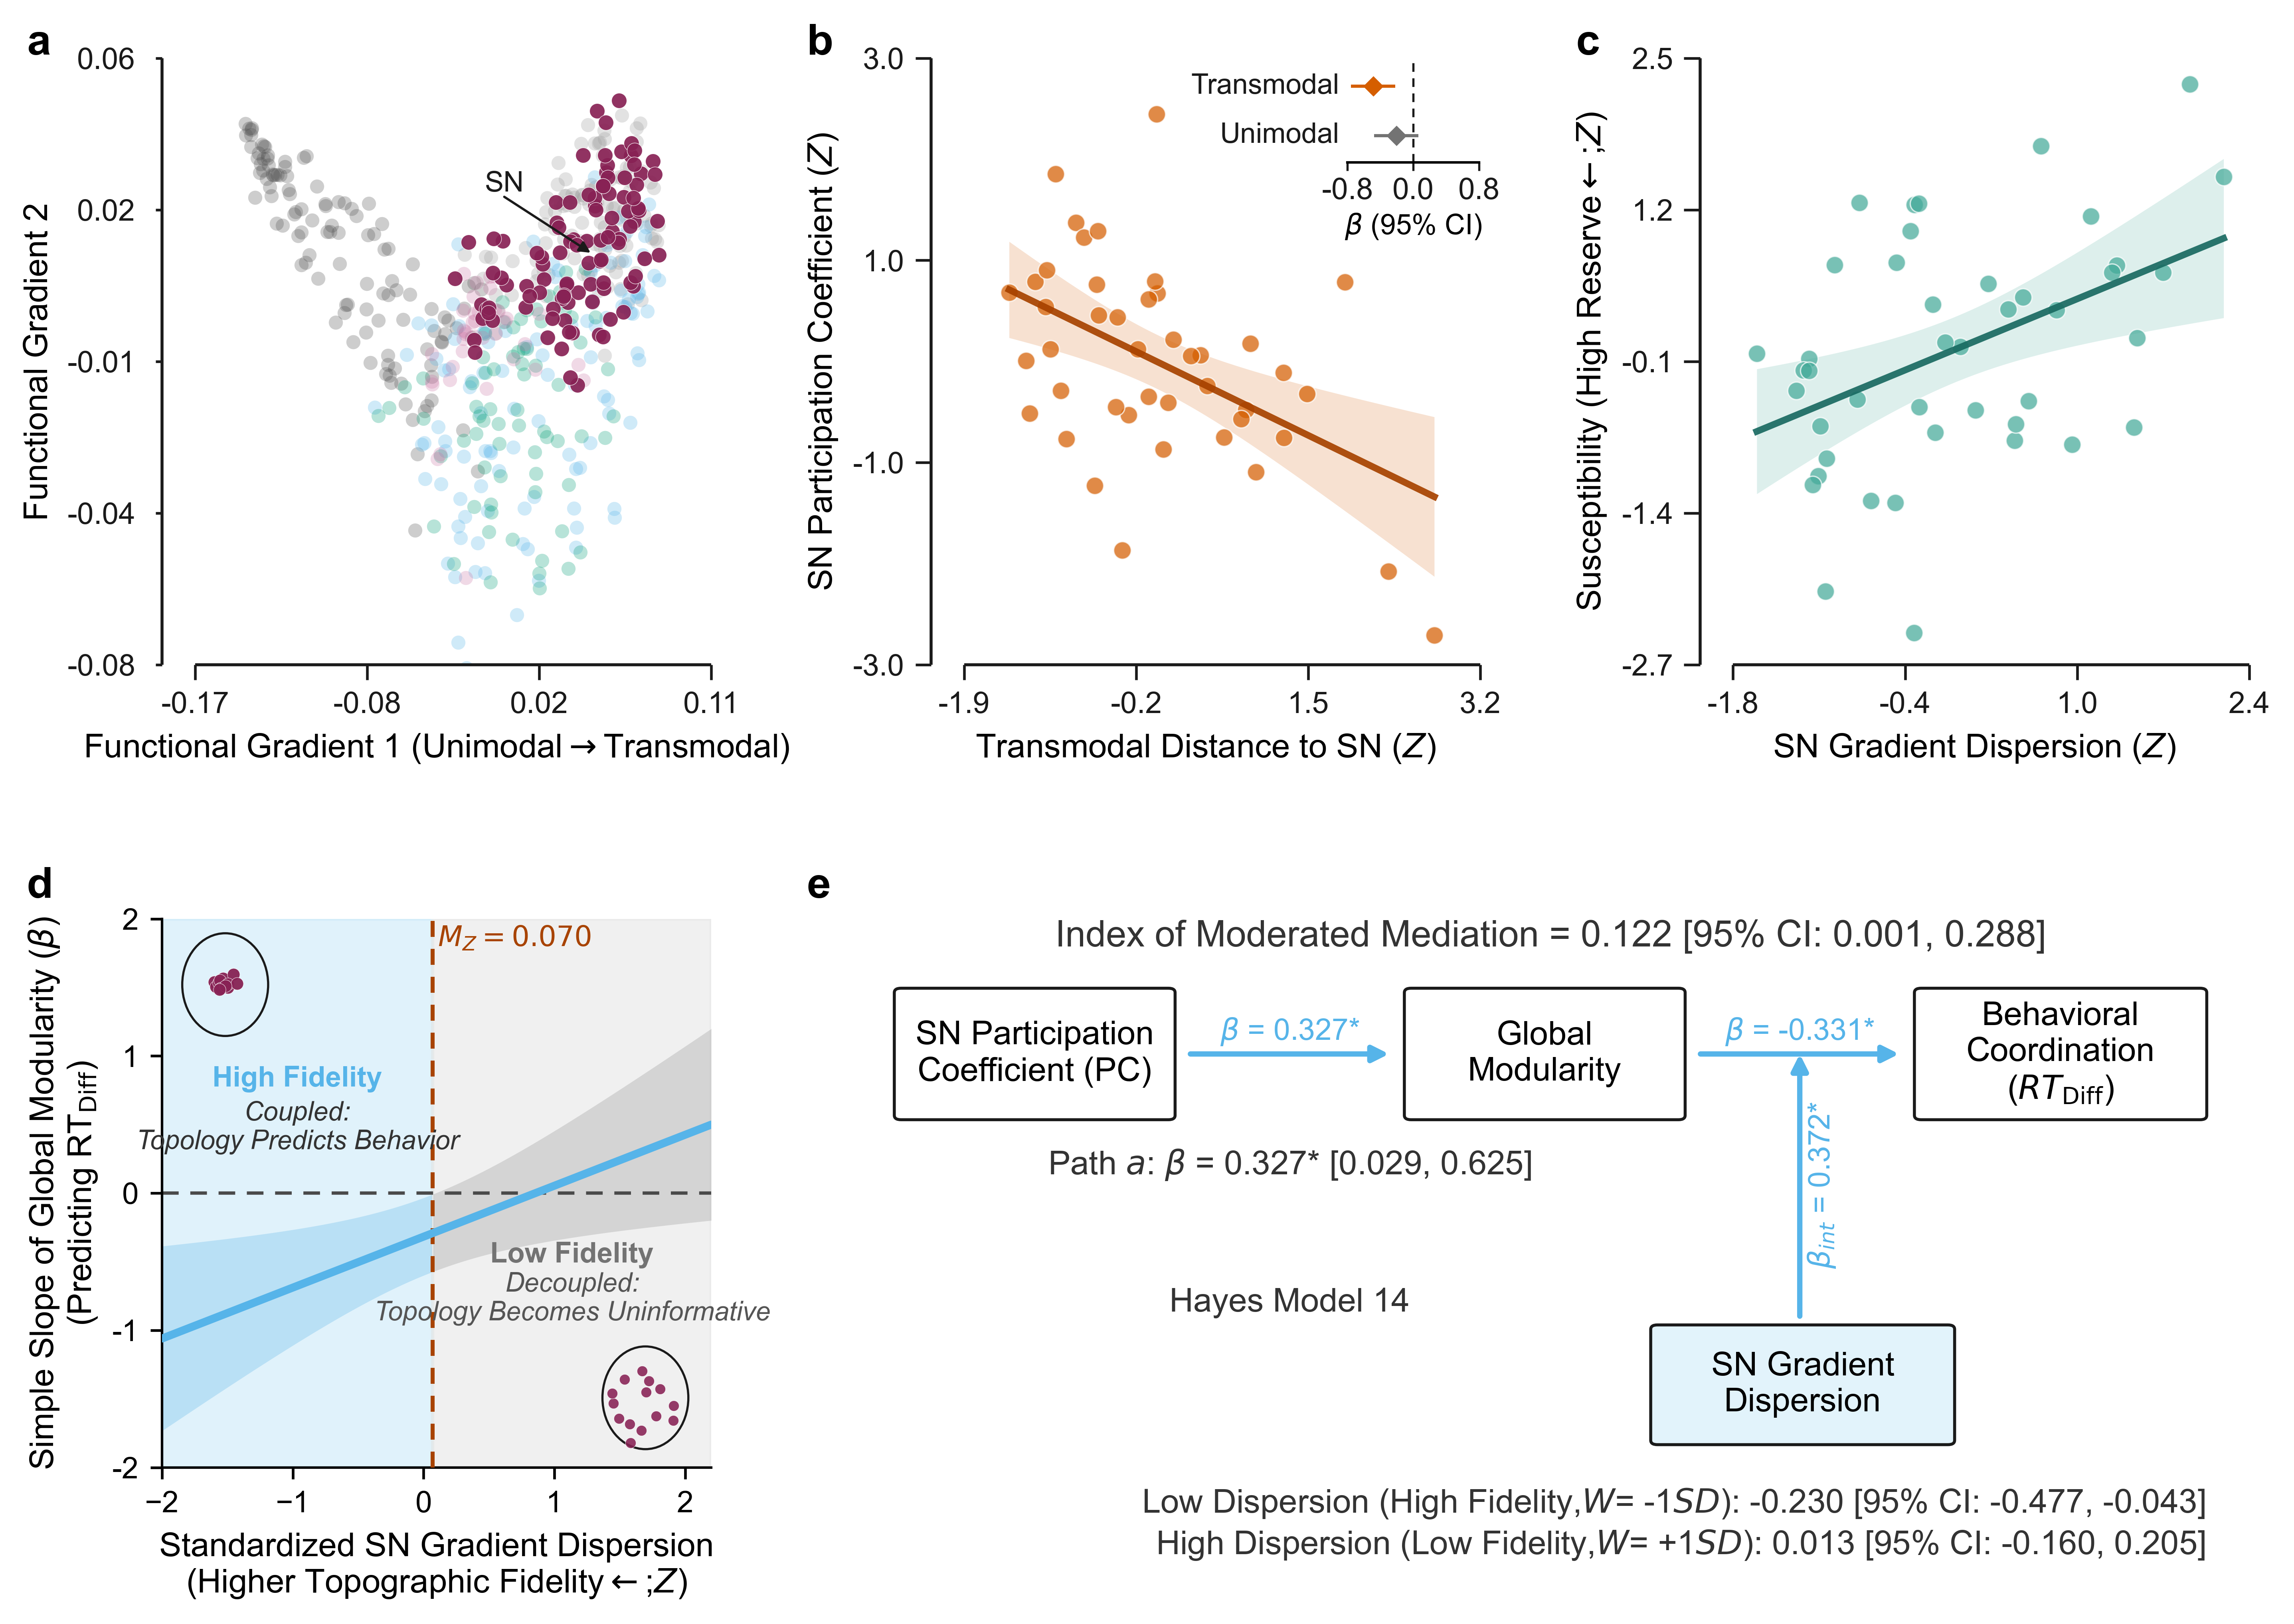

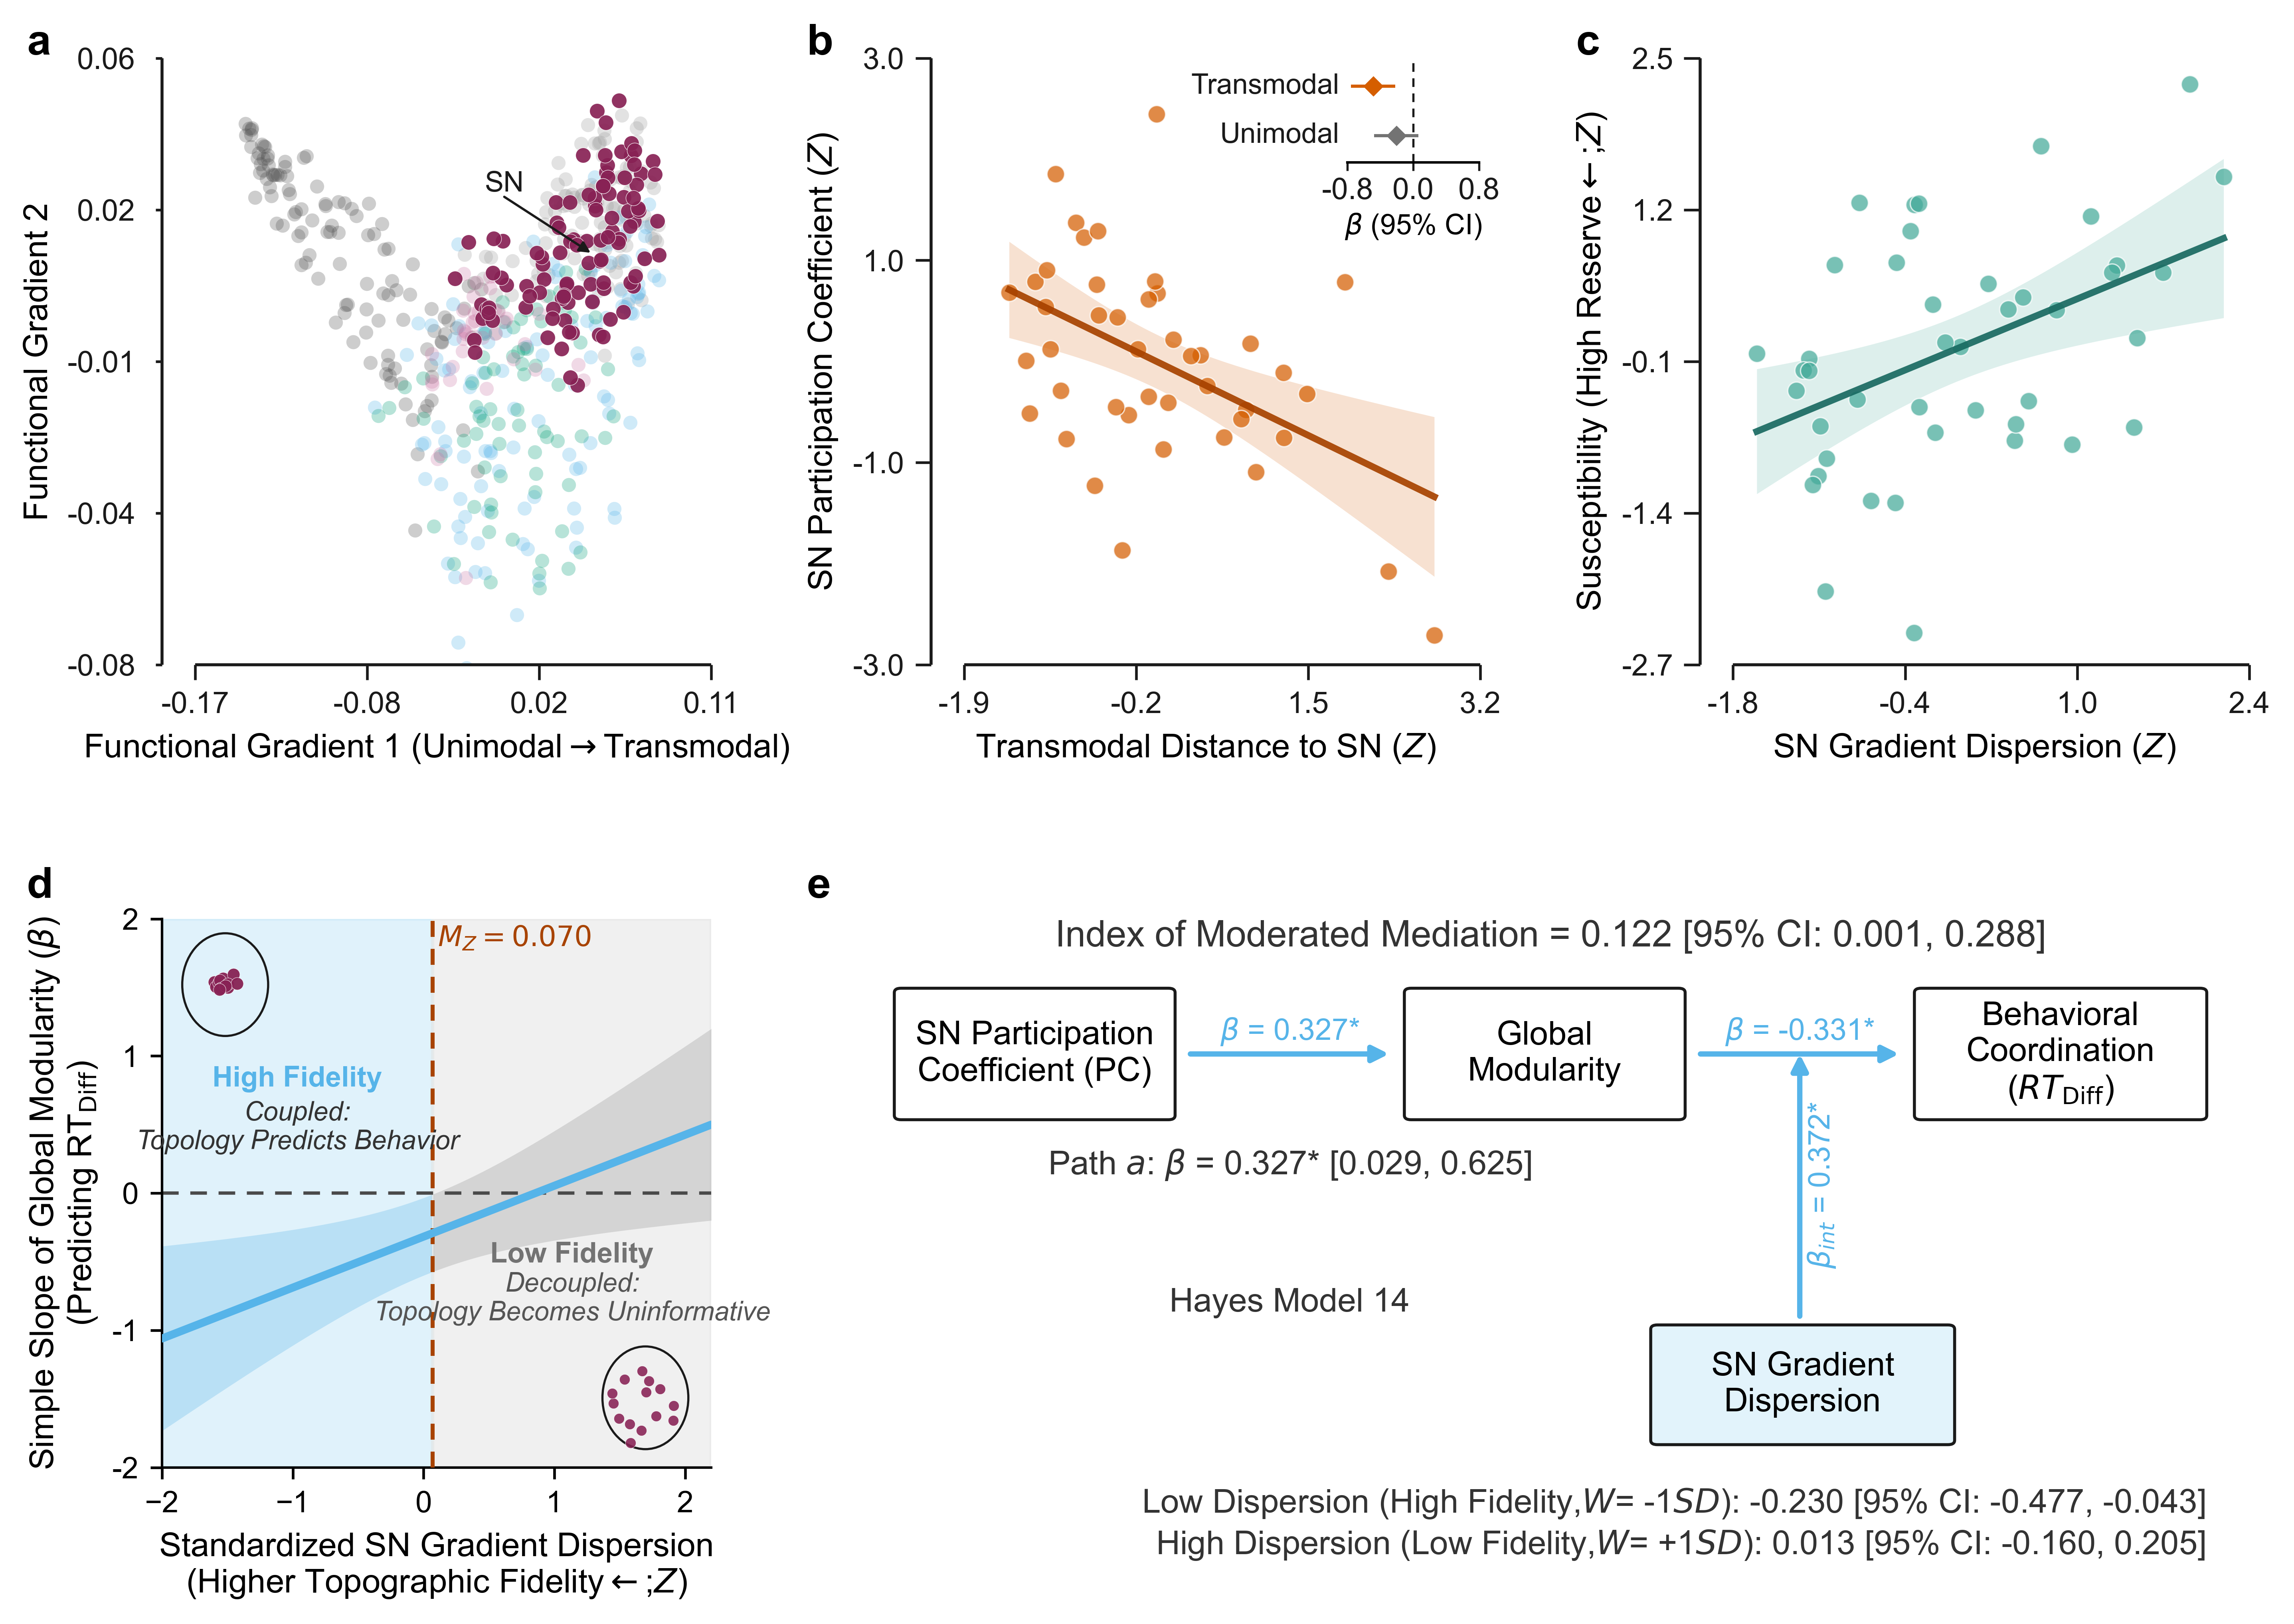

In [1]:
"""Main figure assembly and export."""

import matplotlib.gridspec as gridspec

import matplotlib.pyplot as plt

from pathlib import Path

import pandas as pd


NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "data").is_dir():
    GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT = NOTEBOOK_DIR
else:
    GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT / "data"

OUT_BASENAME = "macro_gradients_topographic_fidelity"

FIGURES_DIR = GRADIENT_DISPERSION_MEDIATE_MODERATE_ROOT / "figures"

OUT_DIR = FIGURES_DIR


def _ensure_prerequisites() -> None:
    """Load 01/02 when this notebook is run without prior cells in the same kernel."""
    if "fit_gradient_regression" in globals() and "panel_a" in globals():
        return
    import json

    nb_dir = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "notebooks"
    for nb_name in ("01_statistics.ipynb", "02_panel_plotting.ipynb"):
        nb_path = nb_dir / nb_name
        if not nb_path.is_file():
            raise RuntimeError(
                f"Missing prerequisite notebook: {nb_path}. "
                "Run 01_statistics.ipynb and 02_panel_plotting.ipynb first."
            )
        nb = json.loads(nb_path.read_text(encoding="utf-8"))
        for cell in nb["cells"]:
            if cell["cell_type"] != "code":
                continue
            src = "".join(cell["source"])
            lines = [ln for ln in src.splitlines() if not ln.strip().startswith("%")]
            code = "\n".join(lines).strip()
            if not code:
                continue
            exec(compile(code, f"{nb_name}", "exec"), globals())


_ensure_prerequisites()


def _in_notebook() -> bool:
    try:
        return get_ipython() is not None
    except NameError:
        return False


def _enable_inline_backend() -> None:
    if not _in_notebook():
        return
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass



def _apply_transparent(fig: plt.Figure) -> None:
    fig.patch.set_facecolor("none")
    fig.patch.set_alpha(0.0)
    for ax in fig.axes:
        ax.set_facecolor("none")
        ax.patch.set_alpha(0.0)



def _place_panel_labels(
    fig: plt.Figure,
    axes: list[plt.Axes],
    letters: str,
    ref_ax: plt.Axes,
    *,
    y_offset: float | None = None,
) -> None:
    """Left-align panel labels with the left edge of the reference panel Y-axis title."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    x_fig = fig.transFigure.inverted().transform(
        (ref_ax.yaxis.label.get_window_extent(renderer).x0, 0)
    )[0]
    y_off = PANEL_LABEL_Y_OFFSET if y_offset is None else y_offset
    for ax, letter in zip(axes, letters, strict=True):
        y_fig = ax.get_position().y1 + y_off
        fig.text(
            x_fig, y_fig, letter,
            transform=fig.transFigure, ha="left", va="bottom",
            fontsize=FS_PANEL, fontweight="bold",
        )


def _sig_stars(p: float) -> str:
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""



def _fig_x_from_axes_data_x(fig: plt.Figure, ax: plt.Axes, x_data: float, y_data: float) -> float:
    """Figure-coordinate x for a point in axes data space."""
    fig.canvas.draw()
    return float(
        fig.transFigure.inverted().transform(ax.transData.transform((x_data, y_data)))[0]
    )


def _e_content_dx_aligned_to_b_yaxis(
    fig: plt.Figure, ax_e: plt.Axes, ax_b: plt.Axes,
) -> float:
    """Offset E content so the leftmost edge aligns with panel B y-axis."""
    y_mid = 0.5 * (PANEL_B_YLIM[0] + PANEL_B_YLIM[1])
    target_x = _fig_x_from_axes_data_x(fig, ax_b, PANEL_B_XLIM[0], y_mid)
    lay_ref = _compute_panel_e_layout(0.0)
    left_data_ref = lay_ref["content_left"] + lay_ref["ox"]
    pos = ax_e.get_position()
    xlim_w = PANEL_E_XLIM[1] - PANEL_E_XLIM[0]
    dx = (target_x - pos.x0) / pos.width * xlim_w + PANEL_E_XLIM[0] - left_data_ref
    return dx + PANEL_E_LAYOUT["d_content_dx_bias"]


def _fig_y_ax_xlabel_bottom(fig: plt.Figure, ax: plt.Axes) -> float:
    """Figure-coordinate y of an axes xlabel bottom edge."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    y_disp = ax.xaxis.label.get_window_extent(renderer).y0
    return float(fig.transFigure.inverted().transform((0.0, y_disp))[1])


def _ax_data_y_from_fig_y(ax: plt.Axes, y_fig: float) -> float:
    pos = ax.get_position()
    y_frac = (y_fig - pos.y0) / pos.height
    return float(ax.transData.inverted().transform(ax.transAxes.transform((0.5, y_frac)))[1])



def _show_figure(fig: plt.Figure) -> None:
    if not _in_notebook():
        plt.show()
        return
    _enable_inline_backend()
    from IPython.display import display

    fig.set_dpi(DPI)
    _apply_transparent(fig)
    display(fig)



ANALYSIS_CSV = DATA_DIR / "analysis_ready.csv"


def load_analysis_df() -> pd.DataFrame:
    if not ANALYSIS_CSV.is_file():
        raise FileNotFoundError(f"Missing analysis table: {ANALYSIS_CSV}")
    return pd.read_csv(ANALYSIS_CSV)

def build_figure(df: pd.DataFrame) -> plt.Figure:
    reg = fit_gradient_regression(df)
    corr = fit_dispersion_correlation(df)
    mod = fit_dispersion_moderation(df)
    med = fit_moderated_mediation(df)
    grad_scatter, panel_a_src, panel_a_empirical = _load_panel_a_embedding()
    print(f"panel a embedding: {panel_a_src}")

    w_in = WIDTH_MM / 25.4
    h_in = HEIGHT_MM / 25.4
    fig = plt.figure(figsize=(w_in, h_in), dpi=DPI, facecolor="none")
    gs = gridspec.GridSpec(
        2, 3, figure=fig,
        height_ratios=[1.05, 0.95],
        width_ratios=[1.2, 1.2, 1.2],
        wspace=0.40, hspace=0.44,
    )
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])
    ax_d = fig.add_subplot(gs[1, 0])
    ax_e = fig.add_subplot(gs[1, 1:])

    panel_a(ax_a, grad_scatter, empirical=panel_a_empirical)
    panel_b(ax_b, reg)
    panel_c(ax_c, corr)
    panel_d(ax_d, mod)

    fig.subplots_adjust(left=0.09, right=0.91, top=0.97, bottom=0.08)
    e_content_dx = _e_content_dx_aligned_to_b_yaxis(fig, ax_e, ax_b)
    panel_e(ax_e, med, ax_d=ax_d, content_dx=e_content_dx)
    _place_panel_labels(fig, [ax_a], "a", ax_d, y_offset=PANEL_LABEL_Y_OFFSET_ABC)
    _place_panel_labels(fig, [ax_b], "b", ax_b, y_offset=PANEL_LABEL_Y_OFFSET_ABC)
    _place_panel_labels(fig, [ax_c], "c", ax_c, y_offset=PANEL_LABEL_Y_OFFSET_ABC)
    _place_panel_labels(fig, [ax_d], "d", ax_d)
    _place_panel_labels(fig, [ax_e], "e", ax_b)
    _apply_transparent(fig)
    return fig


def save_pub(fig: plt.Figure, out_dir: Path, basename: str) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    _apply_transparent(fig)
    save_kw = {
        "bbox_inches": "tight",
        "facecolor": "none",
        "edgecolor": "none",
        "transparent": True,
    }
    fig.savefig(out_dir / f"{basename}.pdf", **save_kw)
    fig.savefig(out_dir / f"{basename}.svg", **save_kw)
    fig.savefig(out_dir / f"{basename}.png", dpi=DPI, **save_kw)
    fig.savefig(out_dir / f"{basename}.eps", format="eps", **save_kw)

%matplotlib inline

df = load_analysis_df()
print(f"N = {len(df)} participants")
reg = fit_gradient_regression(df)
corr = fit_dispersion_correlation(df)
mod = fit_dispersion_moderation(df)
med = fit_moderated_mediation(df)
print(
    f"Regression F={reg['model'].fvalue:.2f}, p={reg['model'].f_pvalue:.4f}, "
    f"R^2={reg['model'].rsquared:.3f}"
)
print(f"Dispersion-RT r={corr['r']:.2f}, p={corr['p']:.4f}")
print(f"Moderation interaction b3={mod['b3']:.3f}, p={mod['p_b3']:.4f}")
print(
    f"Moderated mediation index={med['imm']:.3f}, "
    f"CI [{med['imm_ci'][0]:.3f}, {med['imm_ci'][1]:.3f}]"
)
fig = build_figure(df)
save_pub(fig, OUT_DIR, OUT_BASENAME)
print(f"Saved Figure ({DPI} DPI, transparent) to {OUT_DIR / OUT_BASENAME}.pdf")
_show_figure(fig)
